# Museum Indoor vs Outdoor — CNN Image Classification (PyTorch)

**Pipeline:** EDA → Preprocessing & augmentation → Custom CNN → Hyperparameter tuning →
Pretrained ResNet18 comparison → Evaluation (accuracy, precision, recall, F1, confusion matrix) →
Save/load model → Test-set inference → Application mode (single image / live demo).

**Data layout (Google Drive):**
```
MyDrive/appliedAI/
├── training/            ← split automatically into train/val (stratified, seeded)
│   ├── museum-indoor/
│   └── museum-outdoor/
├── museum_validation/   ← held-out labeled TEST set (never used for training)
│   ├── museum-indoor/
│   └── museum-outdoor/
└── test/                ← unlabeled images (application mode)
```

Designed for **free Colab (T4 GPU)**: 128×128 inputs for the custom CNN, short tuning runs,
early stopping, and only 3 fine-tuning epochs for ResNet18.

**Session-safe:** every training run checkpoints to Google Drive after each epoch.
If Colab disconnects, just reconnect and re-run the notebook — completed experiments are
skipped/resumed from their checkpoints instead of retrained.

## 0. Setup

In [1]:
import os, random, time, copy, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Reproducibility -----------------------------------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
# Mount Google Drive (Colab only)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_ROOT = Path("/content/drive/MyDrive/appliedAI")
except ImportError:
    DATA_ROOT = Path("./appliedAI")  # local fallback

TRAIN_DIR = DATA_ROOT / "training"
HELDOUT_DIR = DATA_ROOT / "museum_validation"   # used as final TEST set
UNLABELED_DIR = DATA_ROOT / "test"              # application mode
CHECKPOINT_DIR = DATA_ROOT / 'checkpoints'
# ── Cache the full HP search summary on Drive ──────────────────────────────
RES_DF_CACHE = CHECKPOINT_DIR / "hp_search_results.csv"
# IMPORTANT (free Colab): models and checkpoints are saved ON GOOGLE DRIVE, so nothing is
# lost if the session disconnects. Re-running the notebook RESUMES training automatically.
EDA_CACHE_SCAN   = CHECKPOINT_DIR / 'eda_train_scan.csv'
EDA_CACHE_COLOR  = CHECKPOINT_DIR / 'eda_color_stats.csv'
MODEL_DIR = DATA_ROOT / "models"        # final trained models (.pt)
CKPT_DIR  = DATA_ROOT / "checkpoints"   # per-epoch resumable checkpoints
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
assert TRAIN_DIR.exists(), f"Dataset not found at {TRAIN_DIR}"

Mounted at /content/drive


In [3]:
# Global configuration ------------------------------------------------------
CFG = dict(
    img_size      = 128,      # custom CNN input size
    resnet_size   = 224,      # ResNet18 expects ImageNet-like inputs
    batch_size    = 64,
    lr            = 1e-3,
    epochs_full   = 15,       # baseline / final runs (early stopping cuts this short)
    epochs_search = 5,        # short runs for hyperparameter comparison
    patience      = 3,        # early-stopping patience (epochs without val-loss improvement)
    val_fraction  = 0.2,      # automated stratified split of training/
    num_workers   = 0,
)
CLASS_NAMES = ["museum-indoor", "museum-outdoor"]

## I. Exploratory Data Analysis (EDA)

We inspect class balance, image dimensions, and color/brightness statistics to justify
preprocessing choices (resize target, normalization, augmentation).

In [5]:
def scan_folder(folder: Path) -> pd.DataFrame:
    """Collect (path, class, width, height) for every image under folder/<class>/."""
    rows = []
    for cls_dir in sorted(p for p in folder.iterdir() if p.is_dir()):
        for img_path in cls_dir.iterdir():
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                with Image.open(img_path) as im:
                    rows.append((str(img_path), cls_dir.name, im.width, im.height, im.mode))
    return pd.DataFrame(rows, columns=["path", "label", "width", "height", "mode"])

# ── Cached load: skip the 10000-image scan if cache exists ───────────────────
if EDA_CACHE_SCAN.exists():
    eda_df = pd.read_csv(EDA_CACHE_SCAN)
    print(f'  [CACHED] Loaded EDA scan from {EDA_CACHE_SCAN.name}  ({len(eda_df)} rows)')
else:
    print('  Scanning training folder (one-time, ~30-60s)...')
    eda_df = scan_folder(TRAIN_DIR)
    eda_df.to_csv(EDA_CACHE_SCAN, index=False)
    print(f'  [SAVED] EDA scan → {EDA_CACHE_SCAN.name}')

print(f"Total training images: {len(eda_df)}")
print(eda_df["label"].value_counts())          # class balance
print(eda_df["mode"].value_counts())           # color modes (expect RGB)
eda_df[["width", "height"]].describe()

  [CACHED] Loaded EDA scan from eda_train_scan.csv  (10000 rows)
Total training images: 10000
label
museum-indoor     5000
museum-outdoor    5000
Name: count, dtype: int64
mode
RGB    10000
Name: count, dtype: int64


,width,height
count,10000.0,10000.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


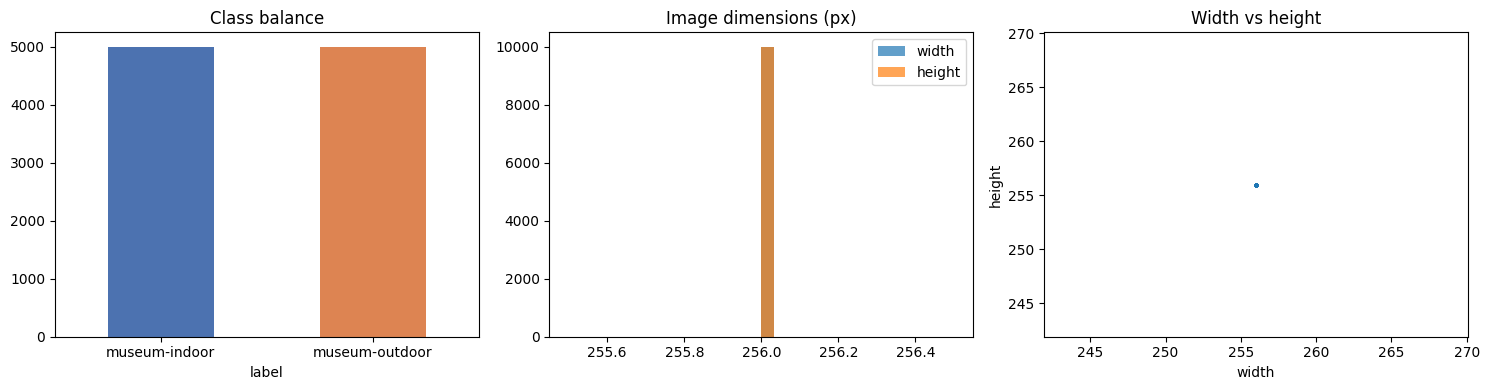

In [6]:
# Class balance + size distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
eda_df["label"].value_counts().plot.bar(ax=axes[0], color=["#4C72B0", "#DD8452"], rot=0)
axes[0].set_title("Class balance")
axes[1].hist(eda_df["width"], bins=30, alpha=.7, label="width")
axes[1].hist(eda_df["height"], bins=30, alpha=.7, label="height")
axes[1].set_title("Image dimensions (px)"); axes[1].legend()
axes[2].scatter(eda_df["width"], eda_df["height"], s=2, alpha=.2)
axes[2].set_title("Width vs height"); axes[2].set_xlabel("width"); axes[2].set_ylabel("height")
plt.tight_layout(); plt.show()

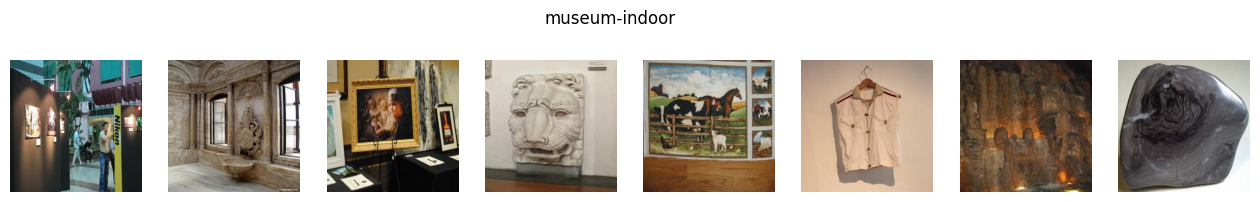

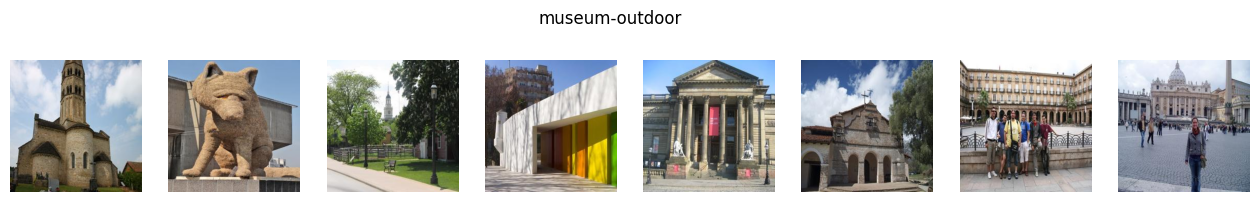

In [ ]:
# Sample grid per class
def show_samples(df, label, n=8):
    paths = df[df.label == label].sample(n, random_state=SEED)["path"].tolist()
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.4))
    for ax, p in zip(axes, paths):
        ax.imshow(Image.open(p).convert("RGB")); ax.axis("off")
    fig.suptitle(label); plt.show()

for c in CLASS_NAMES:
    show_samples(eda_df, c)

  [CACHED] Loaded color stats from eda_color_stats.csv  (600 rows)
                    R      G      B  brightness
label                                          
museum-indoor   0.466  0.421  0.366       0.418
museum-outdoor  0.482  0.492  0.491       0.489


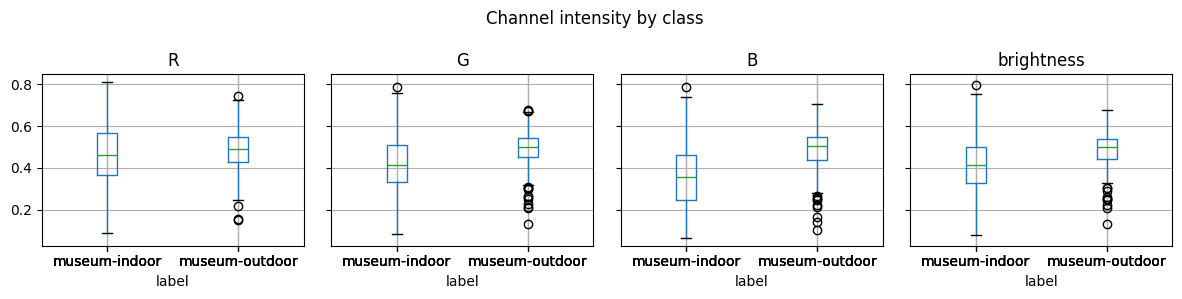

In [7]:
# Color statistics on a random sample (mean RGB intensity & brightness per class)
def color_stats(df, n_per_class=300):
    recs = []
    for label in df.label.unique():
        for p in df[df.label == label].sample(n_per_class, random_state=SEED)["path"]:
            arr = np.asarray(Image.open(p).convert("RGB").resize((64, 64)), dtype=np.float32) / 255.
            recs.append((label, *arr.mean(axis=(0, 1)), arr.mean()))
    return pd.DataFrame(recs, columns=["label", "R", "G", "B", "brightness"])

# ── Cached load: skip the 600-image color sample if cache exists ────────────
if EDA_CACHE_COLOR.exists():
    cs = pd.read_csv(EDA_CACHE_COLOR)
    print(f'  [CACHED] Loaded color stats from {EDA_CACHE_COLOR.name}  ({len(cs)} rows)')
else:
    print('  Computing color stats on random sample (one-time, ~30s)...')
    cs = color_stats(eda_df)
    cs.to_csv(EDA_CACHE_COLOR, index=False)
    print(f'  [SAVED] color stats → {EDA_CACHE_COLOR.name}')

print(cs.groupby("label").mean(numeric_only=True).round(3))

cs.boxplot(column=["R", "G", "B", "brightness"], by="label", figsize=(12, 3), layout=(1, 4))
plt.suptitle("Channel intensity by class"); plt.tight_layout(); plt.show()

**EDA conclusions:** classes are balanced (~5000/5000); images are color (RGB) with varying
dimensions → we resize to a fixed square input. Outdoor images tend to be brighter with a
stronger blue channel (sky), indoor images warmer/darker — color is informative, so we keep
all 3 channels and use only mild color jitter in augmentation.

## II. Preprocessing: resize, normalization, data augmentation, automated split

* **Resize** to 128×128 (custom CNN) — keeps free-Colab training fast.
* **Normalization** with the dataset's own channel mean/std (computed below).
* **Augmentation** (train only): random horizontal flip, small rotation, random resized crop,
  mild color jitter — effectively enlarges our 10k-image dataset and fights overfitting.
* **Automated split**: stratified, seeded `train_test_split` over the indices of `training/`
  (no manual image selection). `museum_validation/` is kept as the untouched final test set.

In [ ]:
# Compute dataset channel mean/std from a sample of training images
def compute_mean_std(df, n=1000, size=64):
    sample = df.sample(min(n, len(df)), random_state=SEED)["path"]
    acc = np.stack([np.asarray(Image.open(p).convert("RGB").resize((size, size)),
                               dtype=np.float32) / 255. for p in sample])
    return acc.mean(axis=(0, 1, 2)), acc.std(axis=(0, 1, 2))

DATA_MEAN, DATA_STD = compute_mean_std(eda_df)
print("mean:", DATA_MEAN.round(3), "std:", DATA_STD.round(3))

mean: [0.478 0.458 0.43 ] std: [0.255 0.253 0.276]


In [8]:
S = CFG["img_size"]
# ImageNet normalization applied to BOTH pipelines (custom CNN and ResNet18): keeps the
# comparison controlled (same input) AND gives ResNet the format it was pretrained on.
# For the custom CNN (trained from scratch + BatchNorm) the choice is ~irrelevant.
NORM_MEAN, NORM_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(S, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

# Two ImageFolder views of the same folder, different transforms
full_train_aug  = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
full_train_eval = datasets.ImageFolder(TRAIN_DIR, transform=eval_tf)
assert full_train_aug.classes == CLASS_NAMES, full_train_aug.classes

# AUTOMATED stratified split
idx = np.arange(len(full_train_aug))
train_idx, val_idx = train_test_split(
    idx, test_size=CFG["val_fraction"], stratify=full_train_aug.targets, random_state=SEED)

train_ds = Subset(full_train_aug,  train_idx)   # augmented
val_ds   = Subset(full_train_eval, val_idx)     # no augmentation
test_ds  = datasets.ImageFolder(HELDOUT_DIR, transform=eval_tf)  # final held-out test

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

def make_loaders(batch_size):
    kw = dict(num_workers=CFG["num_workers"], pin_memory=True)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw),
            DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw))

train_loader, val_loader, test_loader = make_loaders(CFG["batch_size"])

train=8000  val=2000  test=200


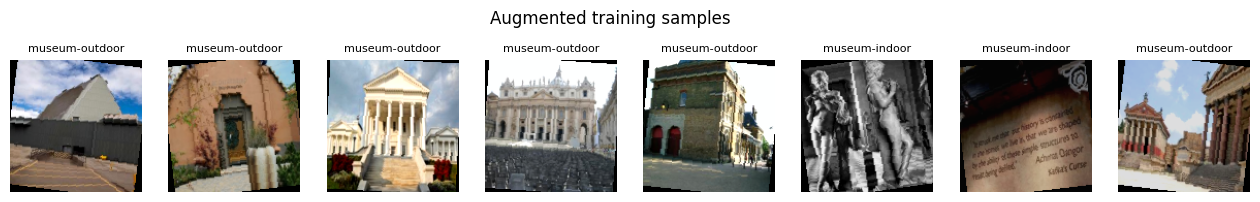

In [ ]:
# Visual check: augmented batch
def denorm(t): return (t.permute(1, 2, 0).numpy() * np.array(NORM_STD) + np.array(NORM_MEAN)).clip(0, 1)
xb, yb = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
for ax, img, y in zip(axes, xb, yb):
    ax.imshow(denorm(img)); ax.set_title(CLASS_NAMES[y], fontsize=8); ax.axis("off")
plt.suptitle("Augmented training samples"); plt.show()

## III. Custom CNN architecture

VGG-inspired stack of `Conv → BatchNorm → ReLU → MaxPool` blocks with doubling channel
widths (32→64→128→…), then `AdaptiveAvgPool → Dropout → FC`. Design choices:

* **Why this architecture?** Small VGG-style nets are a proven fit for binary scene
  classification; BatchNorm stabilizes training, AdaptiveAvgPool makes the head independent
  of input size and keeps parameter count low (less overfitting than big FC layers).
* **Weight initialization:** **He (Kaiming)** — designed for ReLU networks; keeps activation
  variance stable through depth (Xavier targets tanh/sigmoid).
* **Configurable** `n_blocks` (number of convolutional layers) and `n_pools` (number of
  pooling layers) → these are exactly the two required architecture hyperparameters.
* **For 10 classes instead of 2:** only `n_classes` changes (final FC layer width) — the
  rest of the pipeline is class-count agnostic.

### Architecture flowchart (baseline: 3 blocks, input 3×128×128)

```
                 INPUT  RGB image  (3 × 128 × 128)
                           │
╔══════════ PART 1 — FEATURE EXTRACTOR (self.features) ══════════╗
║                                                                ║
║  Block 1:  Conv3×3(3→32) → BatchNorm → ReLU → MaxPool2×2       ║
║            output: 32 × 64 × 64   (Ex:learns edges/colors)     ║
║                            │                                   ║
║  Block 2:  Conv3×3(32→64) → BatchNorm → ReLU → MaxPool2×2      ║
║            output: 64 × 32 × 32   (Ex:learns textures/patterns)║
║                            │                                   ║
║  Block 3:  Conv3×3(64→128) → BatchNorm → ReLU → MaxPool2×2     ║
║            output: 128 × 16 × 16(EX:learns objects/scene parts)║
╚════════════════════════════════════════════════════════════════╝
                           │
╔══════════ PART 2 — CLASSIFIER (self.classifier) ═══════════════╗
║                                                                ║
║  AdaptiveAvgPool(4×4)   → 128 × 4 × 4                          ║
║  Flatten                → vector of 2048                       ║
║  Dropout(0.5)           → regularization                       ║
║  Linear(2048 → 128) + ReLU                                     ║
║  Dropout(0.5)                                                  ║
║  Linear(128 → 2)        → logits [indoor, outdoor]             ║
╚════════════════════════════════════════════════════════════════╝
                           │
                 Softmax → P(indoor), P(outdoor)
```

In [9]:
# ---- Shared classifier HEAD (used by BOTH the custom CNN and the ResNet18 pipeline) ----
# Pure PyTorch. Keeping ONE definition guarantees the two pipelines differ ONLY in the
# FEATURE EXTRACTOR: the classification head is literally the same module design. The only
# value that changes is `in_ch` (channels the extractor outputs): 128 for the custom CNN,
# 512 for ResNet18 -> this just sets the width of the head's first Linear.
def make_classifier(in_ch, n_classes=2, dropout=0.5):
    """AdaptiveAvgPool(4x4) -> Flatten -> Dropout -> Linear(in_ch*16 -> 128) -> ReLU
    -> Dropout -> Linear(128 -> n_classes). AdaptiveAvgPool makes the head independent
    of the input spatial size (works for 128px or 224px inputs alike)."""
    return nn.Sequential(
        nn.AdaptiveAvgPool2d((4, 4)),
        nn.Flatten(),
        nn.Dropout(dropout),
        nn.Linear(in_ch * 4 * 4, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(128, n_classes),
    )


def he_init(m):
    """He (Kaiming) initialization - appropriate for ReLU activations."""
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)


class MuseumCNN(nn.Module):
    """Custom CNN in TWO explicit parts:

    PART 1 - self.features  : FEATURE EXTRACTOR (convolutional blocks).
    PART 2 - self.classifier: CLASSIFIER (shared make_classifier head).

    Configurable: n_blocks = number of convolutional layers,
                  n_pools  = number of pooling layers (first n_pools blocks get MaxPool).
    """

    def __init__(self, n_blocks=3, n_pools=None, base_channels=32,
                 dropout=0.5, n_classes=2):
        super().__init__()
        n_pools = n_blocks if n_pools is None else n_pools

        # ----------------- PART 1: FEATURE EXTRACTOR -----------------
        # Each block = Conv3x3 -> BatchNorm -> ReLU -> (MaxPool). Channels double each
        # block (32 -> 64 -> 128 ...): deeper layers encode more feature types over less
        # spatial resolution.
        layers, in_ch = [], 3                      # input has 3 channels (RGB)
        for b in range(n_blocks):
            out_ch = base_channels * (2 ** b)      # 32, 64, 128, ...
            layers += [nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                       nn.BatchNorm2d(out_ch),
                       nn.ReLU(inplace=True)]
            if b < n_pools:                        # pooling only in the first n_pools blocks
                layers.append(nn.MaxPool2d(2))
            in_ch = out_ch
        self.features = nn.Sequential(*layers)

        # ----------------- PART 2: CLASSIFIER (shared head) -----------------
        # SAME factory used by the ResNet18 pipeline -> the two models share an identical
        # head design; only `in_ch` differs (here = last conv channel count).
        self.classifier = make_classifier(in_ch, n_classes=n_classes, dropout=dropout)

        # He (Kaiming) init for every Conv/Linear layer (whole net trained from scratch).
        self.apply(he_init)

    def forward(self, x):
        x = self.features(x)      # PART 1: image -> feature maps
        x = self.classifier(x)    # PART 2: feature maps -> class logits
        return x

print(MuseumCNN())
n_params = sum(p.numel() for p in MuseumCNN().parameters())
print(f"Parameters: {n_params:,}")


MuseumCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 4))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dr

## IV. Training / evaluation utilities

* **Optimizer: Adam** — adaptive per-parameter learning rates converge quickly on the few
  epochs free Colab allows (SGD is compared in the tuning section).
* **Loss:** CrossEntropy. **Anti-overfitting:** augmentation, dropout, BatchNorm,
  weight decay, and **early stopping** on validation loss (also answers "how were the
  number of epochs chosen?" — by early stopping, capped at `epochs_full`).
* **Checkpoints (free Colab):** training state is saved to Drive after every epoch
  (`appliedAI/checkpoints/<tag>_ckpt.pt`). If the session dies, re-run the same cell
  and training **resumes automatically** from the last completed epoch.

In [15]:
def run_epoch(model, loader, criterion, optimizer=None):
    """One pass over loader. Trains if optimizer is given, else evaluates."""
    training = optimizer is not None
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            n += len(yb)
    return total_loss / n, correct / n


def fit(model, train_loader, val_loader, epochs, lr=1e-3, optimizer_name="adam",
        weight_decay=1e-4, patience=CFG["patience"], tag="model", resume=True):
    """Full training loop with early stopping AND resumable checkpoints.

    CHECKPOINTING (free Colab safety): after EVERY epoch, the full training state
    (model + optimizer + history + early-stopping counters) is saved to Google Drive
    at  checkpoints/<tag>_ckpt.pt . If the session disconnects, just re-run the same
    cell: training resumes from the last completed epoch instead of starting over.
    Set resume=False (or delete the file) to force training from scratch.
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    # --- optimizer ---
    if optimizer_name == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                              weight_decay=weight_decay)
    else:
        raise ValueError(optimizer_name)

    # --- fresh training state ---
    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc"]}
    best_val, best_state, bad_epochs, start_epoch = float("inf"), None, 0, 1

    # --- RESUME from checkpoint if one exists on Drive ---
    ckpt_path = CKPT_DIR / f"{tag}_ckpt.pt"
    if resume and ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ck["model"])
        opt.load_state_dict(ck["optimizer"])
        hist, best_val = ck["hist"], ck["best_val"]
        best_state, bad_epochs = ck["best_state"], ck["bad_epochs"]
        start_epoch = ck["epoch"] + 1
        print(f"[{tag}] resumed from checkpoint — epoch {ck['epoch']} "
              f"(best val loss {best_val:.4f})")

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, opt)   # train pass
        va_loss, va_acc = run_epoch(model, val_loader, criterion)          # validation pass
        for k, v in zip(hist, [tr_loss, tr_acc, va_loss, va_acc]):
            hist[k].append(v)
        print(f"[{tag}] epoch {epoch:02d}/{epochs}  "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.4f}  ({time.time()-t0:.0f}s)")

        # --- early stopping bookkeeping ---
        if va_loss < best_val - 1e-4:
            best_val, best_state, bad_epochs = va_loss, copy.deepcopy(model.state_dict()), 0
        else:
            bad_epochs += 1

        # --- SAVE CHECKPOINT to Drive (every epoch) ---
        torch.save({"epoch": epoch, "model": model.state_dict(),
                    "optimizer": opt.state_dict(), "hist": hist,
                    "best_val": best_val, "best_state": best_state,
                    "bad_epochs": bad_epochs}, ckpt_path)

        if bad_epochs >= patience:
            print(f"[{tag}] early stopping (no val improvement for {patience} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)   # restore the best-validation weights
    return model, hist


def plot_history(hist, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(hist["train_loss"], label="train"); axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss"); axes[0].legend()
    axes[1].plot(hist["train_acc"], label="train"); axes[1].plot(hist["val_acc"], label="val")
    axes[1].set_title(f"{title} — accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()


@torch.no_grad()
def get_predictions(model, loader):
    """Return y_true, y_pred, y_prob for a loader."""
    model.eval().to(DEVICE)
    ys, ps, probs = [], [], []
    for xb, yb in loader:
        out = F.softmax(model(xb.to(DEVICE)), dim=1).cpu()
        ys.append(yb); ps.append(out.argmax(1)); probs.append(out)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy(), torch.cat(probs).numpy()


def evaluate_model(model, loader, name="model", show_cm=True):
    """Per-class + overall accuracy/precision/recall/F1 and confusion matrix."""
    y, yhat, _ = get_predictions(model, loader)
    print(f"\n===== {name} =====")
    print(classification_report(y, yhat, target_names=CLASS_NAMES, digits=4))
    if show_cm:
        cm = confusion_matrix(y, yhat)
        ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap="Blues")
        plt.title(f"Confusion matrix — {name}"); plt.show()
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, average="macro")
    return dict(model=name, accuracy=accuracy_score(y, yhat),
                precision=p, recall=r, f1=f1)

## V. Baseline training (custom CNN)

[baseline] resumed from checkpoint — epoch 15 (best val loss 0.1686)


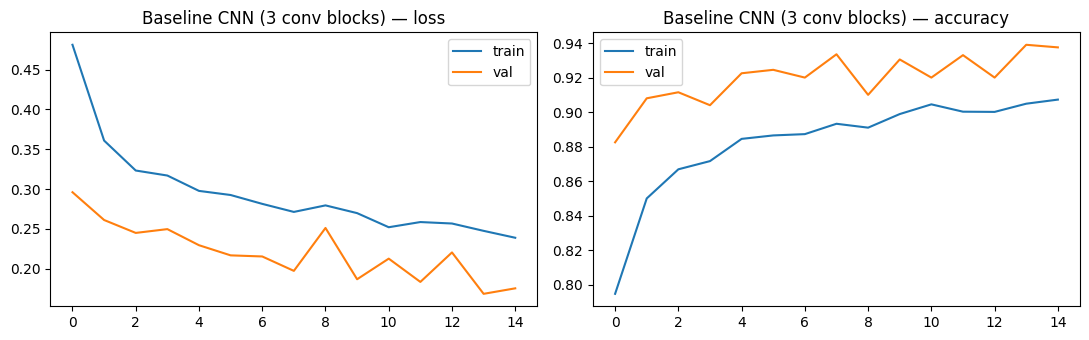

saved → /content/drive/MyDrive/appliedAI/models/museum_cnn_baseline.pt


In [22]:
baseline = MuseumCNN(n_blocks=3)
baseline, hist_base = fit(baseline, train_loader, val_loader,
                          epochs=CFG["epochs_full"], lr=CFG["lr"], tag="baseline")
plot_history(hist_base, "Baseline CNN (3 conv blocks)")

# Save the trained model (architecture config + weights + normalization stats)
def save_model(model, path, arch_kwargs):
    torch.save({"state_dict": model.state_dict(), "arch_kwargs": arch_kwargs,
                "mean": NORM_MEAN, "std": NORM_STD,
                "classes": CLASS_NAMES}, path)
    print("saved →", path)

save_model(baseline, MODEL_DIR / "museum_cnn_baseline.pt", {"n_blocks": 3})

## VI. Hyperparameter tuning (lightweight — free Colab)

Short runs (`epochs_search=5`, fixed seed) so the *relative* comparison is fair and cheap.
Each experiment checkpoints to Drive under its own tag → finished experiments are skipped
if the session dies and the cell is re-run.

| # | Experiment | What changes | Type |
|---|------------|--------------|------|
| 1 | `blocks_2` / `blocks_4` | **number of convolutional layers** (2/3/4) | architecture (required #1) |
| 2 | `pool_removed` | **remove one pooling layer** (3 convs, 2 pools) | architecture (required #2) |
| 3 | `lr_1e-4` | learning rate 1e-3 → 1e-4 | optimization |
| 4 | `sgd` | Adam → SGD+momentum | optimization |
| 5 | `batch_32` | batch size 64 → 32 | optimization |

Why these? Conv depth and pooling control model **capacity** and spatial information flow
(required by the project spec); LR/optimizer/batch size are the hyperparameters with the
largest documented impact on convergence speed and generalization.

In [16]:
def quick_run(name, model_kwargs=None, fit_kwargs=None, batch_size=None):
    torch.manual_seed(SEED)  # same init randomness for fairness
    model = MuseumCNN(**(model_kwargs or {}))
    tl, vl, _ = make_loaders(batch_size or CFG["batch_size"])
    fk = dict(epochs=CFG["epochs_search"], lr=CFG["lr"], tag=name)
    fk.update(fit_kwargs or {})
    model, hist = fit(model, tl, vl, **fk)
    return dict(experiment=name,
                best_val_acc=max(hist["val_acc"]),
                best_val_loss=min(hist["val_loss"]),
                final_train_acc=hist["train_acc"][-1],
                params=sum(p.numel() for p in model.parameters()))

experiments = [
    ("baseline_3blocks", {},                              {},                       None),
    ("blocks_2",         {"n_blocks": 2},                 {},                       None),  # fewer conv layers
    ("blocks_4",         {"n_blocks": 4},                 {},                       None),  # more conv layers
    ("pool_removed",     {"n_blocks": 3, "n_pools": 2},   {},                       None),  # remove a pooling layer
    ("lr_1e-4",          {},                              {"lr": 1e-4},             None),
    ("sgd_momentum",     {},                              {"optimizer_name": "sgd",
                                                           "lr": 1e-2},             None),
    ("batch_32",         {},                              {},                       32),
]

results = [quick_run(n, mk, fk, bs) for n, mk, fk, bs in experiments]
res_df = pd.DataFrame(results).set_index("experiment").round(4)
res_df

[baseline_3blocks] resumed from checkpoint — epoch 5 (best val loss 0.2331)
[blocks_2] resumed from checkpoint — epoch 5 (best val loss 0.2664)
[blocks_4] resumed from checkpoint — epoch 5 (best val loss 0.2096)
[pool_removed] resumed from checkpoint — epoch 5 (best val loss 0.2120)
[lr_1e-4] resumed from checkpoint — epoch 5 (best val loss 0.2632)
[sgd_momentum] resumed from checkpoint — epoch 5 (best val loss 0.2591)
[batch_32] resumed from checkpoint — epoch 5 (best val loss 0.2452)


,best_val_acc,best_val_loss,final_train_acc,params
experiment,,,,
baseline_3blocks,0.9195,0.2331,0.8795,356226
blocks_2,0.8995,0.2664,0.8601,151042
blocks_4,0.9250,0.2096,0.8860,914050
pool_removed,0.9235,0.2120,0.8810,356226
lr_1e-4,0.9015,0.2632,0.8424,356226
sgd_momentum,0.9125,0.2591,0.8639,356226
batch_32,0.9150,0.2452,0.8804,356226


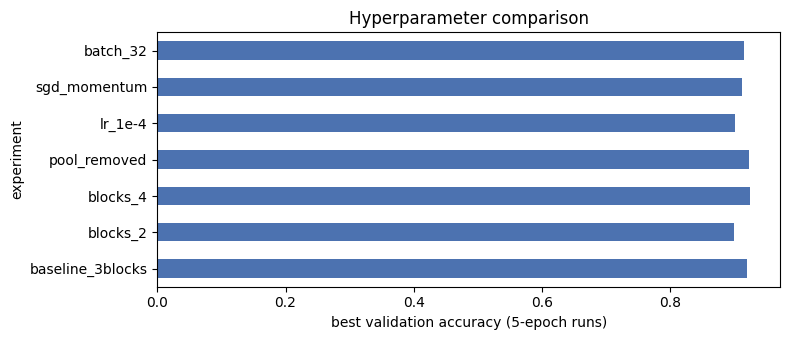

In [17]:
res_df["best_val_acc"].plot.barh(figsize=(8, 3.5), color="#4C72B0")
plt.xlabel("best validation accuracy (5-epoch runs)")
plt.title("Hyperparameter comparison"); plt.tight_layout(); plt.show()

**Reading the table:** pick the configuration with the best validation accuracy/loss and
retrain it fully below. (Edit `BEST_KWARGS`/`BEST_FIT` after inspecting `res_df` on your run.)

[BEST CONFIG] auto-selected from HP search
  winner experiment : blocks_4
  best_val_acc (HP) : 0.9250
  architecture      : {'n_blocks': 4}
  training kwargs   : {'lr': 0.001}
  batch size        : 64
[best_cnn_blocks_4] resumed from checkpoint — epoch 15 (best val loss 0.1677)


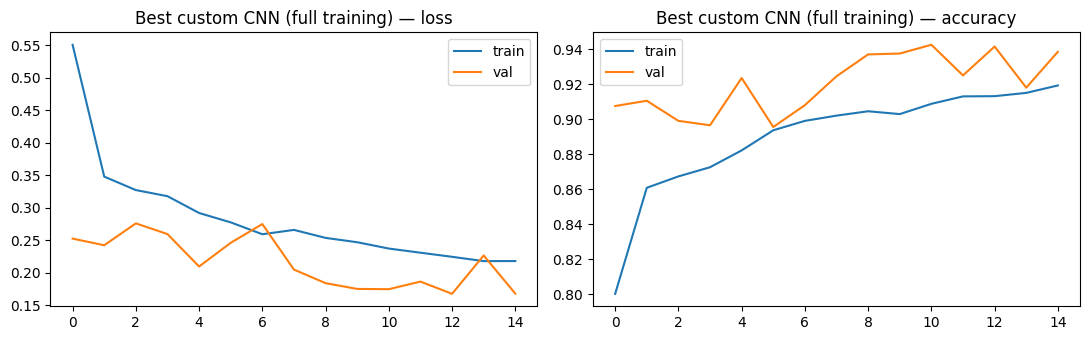

saved → /content/drive/MyDrive/appliedAI/models/museum_cnn_best.pt


In [23]:
# ── Auto-select the winning config from HP search (cell VI) ────────────────
top_name = res_df["best_val_acc"].idxmax()
_, top_kwargs, top_fit, top_batch = next(e for e in experiments if e[0] == top_name)

BEST_KWARGS = dict(top_kwargs)
BEST_FIT    = {"lr": CFG["lr"], **top_fit}
BEST_BATCH  = top_batch or CFG["batch_size"]

print("="*68)
print(f"[BEST CONFIG] auto-selected from HP search")
print(f"  winner experiment : {top_name}")
print(f"  best_val_acc (HP) : {res_df.loc[top_name, 'best_val_acc']:.4f}")
print(f"  architecture      : {BEST_KWARGS}")
print(f"  training kwargs   : {BEST_FIT}")
print(f"  batch size        : {BEST_BATCH}")
print("="*68)

if BEST_BATCH != CFG["batch_size"]:
    best_train_loader, best_val_loader, _ = make_loaders(BEST_BATCH)
else:
    best_train_loader, best_val_loader = train_loader, val_loader

torch.manual_seed(SEED)
best_cnn = MuseumCNN(**BEST_KWARGS)
best_cnn, hist_best = fit(best_cnn, best_train_loader, best_val_loader,
                          epochs=CFG["epochs_full"],
                          tag=f"best_cnn_{top_name}",    # ← unique tag per winning config
                          **BEST_FIT)
plot_history(hist_best, "Best custom CNN (full training)")
save_model(best_cnn, MODEL_DIR / "museum_cnn_best.pt", BEST_KWARGS)

## VII. ResNet18 as a feature extractor (controlled comparison)

**Fair comparison:** the two pipelines differ **only in the feature extractor**.

* **Pipeline A (custom CNN):** convolutional extractor trained from scratch + `make_classifier` head.
* **Pipeline B (ResNet18):** ImageNet-pretrained backbone (`conv1 … layer4`, without the
  original `avgpool`/`fc`) + the **same** `make_classifier` head.

Everything else is kept **identical**: the same input (128×128, ImageNet normalization applied
to both pipelines, the very same `train_loader`/`val_loader`/`test_loader`) and the same
classifier head. The only difference forced by the architecture is the number of channels each
extractor outputs (128 vs 512), which sets the width of the head's first `Linear`.

The backbone is fine-tuned **end-to-end** (`FREEZE_BACKBONE = False`) at a low LR, mirroring the
custom CNN which also trains its whole extractor. Setting `FREEZE_BACKBONE = True` freezes the
backbone and trains only the head (pure transfer learning as a fixed feature extractor).

> Models are implemented in pure PyTorch/torchvision; scikit-learn is used only for evaluation.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


ResNet18 backbone + shared head | freeze_backbone=False
  trainable parameters: 12,225,474
[resnet18_shared] resumed from checkpoint — epoch 3 (best val loss 0.1041)


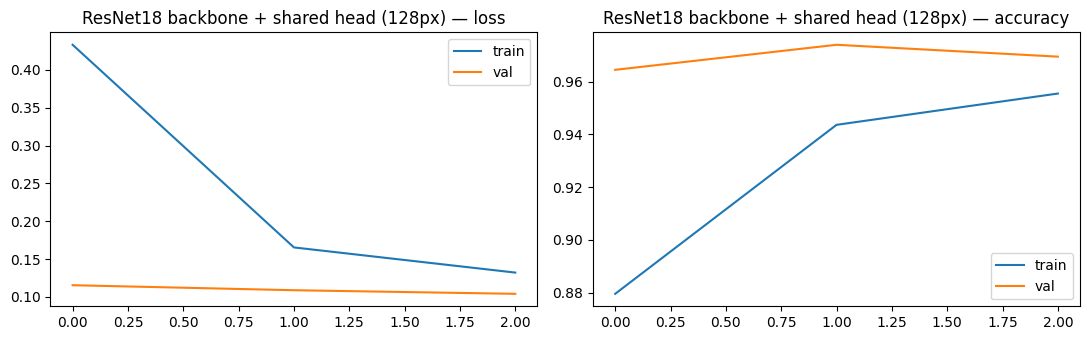

In [19]:
# ============================================================================
# VII. ResNet18 (pretrained) as the EXTRACTOR + the SAME head as the custom CNN.
# Differs from Pipeline A ONLY in the extractor. Uses the SAME 128px loaders
# (input and normalization identical to the custom CNN). Pure PyTorch/torchvision.
# ============================================================================
FREEZE_BACKBONE = False   # False = fine-tune end-to-end (mirrors the custom CNN);
                          # True  = frozen backbone, train only the head.

class ResNetBackboneClassifier(nn.Module):
    """ResNet18 (ImageNet) WITHOUT avgpool/fc as the extractor -> 512-channel map,
    followed by the SAME make_classifier head used by the custom CNN."""

    def __init__(self, n_classes=2, dropout=0.5, freeze_backbone=False, pretrained=True):
        super().__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet18(weights=weights)
        # keep conv1..layer4 (drop avgpool + fc) -> output 512 x H x W
        self.features = nn.Sequential(*list(backbone.children())[:-2])
        if freeze_backbone:
            for prm in self.features.parameters():
                prm.requires_grad = False
        # SAME head as the custom CNN (in_ch=512). Only the head gets He init;
        # the backbone KEEPS its pretrained ImageNet weights.
        self.classifier = make_classifier(512, n_classes=n_classes, dropout=dropout)
        self.classifier.apply(he_init)

    def forward(self, x):
        return self.classifier(self.features(x))


def build_resnet_classifier(freeze_backbone=FREEZE_BACKBONE):
    torch.manual_seed(SEED)
    return ResNetBackboneClassifier(n_classes=len(CLASS_NAMES),
                                    freeze_backbone=freeze_backbone)

torch.manual_seed(SEED)
resnet = build_resnet_classifier(FREEZE_BACKBONE)
n_train = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"ResNet18 backbone + shared head | freeze_backbone={FREEZE_BACKBONE}")
print(f"  trainable parameters: {n_train:,}")

# Train on the SAME 128px loaders as the custom CNN (identical input/normalization).
resnet, hist_rn = fit(resnet, train_loader, val_loader,
                      epochs=3, lr=1e-4, patience=2, tag="resnet18_shared")
plot_history(hist_rn, "ResNet18 backbone + shared head (128px)")
torch.save({"state_dict": resnet.state_dict(), "classes": CLASS_NAMES,
            "arch": "resnet18_backbone+make_classifier", "in_ch": 512,
            "freeze_backbone": FREEZE_BACKBONE},
           MODEL_DIR / "museum_resnet18.pt")


## VIII. Final evaluation on the held-out test set

`museum_validation/` was never touched during training or tuning. We report **per-class and
overall** accuracy, precision, recall, F1, plus confusion matrices, and compare both models.


===== Custom CNN (best) =====
                precision    recall  f1-score   support

 museum-indoor     0.9151    0.9700    0.9417       100
museum-outdoor     0.9681    0.9100    0.9381       100

      accuracy                         0.9400       200
     macro avg     0.9416    0.9400    0.9399       200
  weighted avg     0.9416    0.9400    0.9399       200



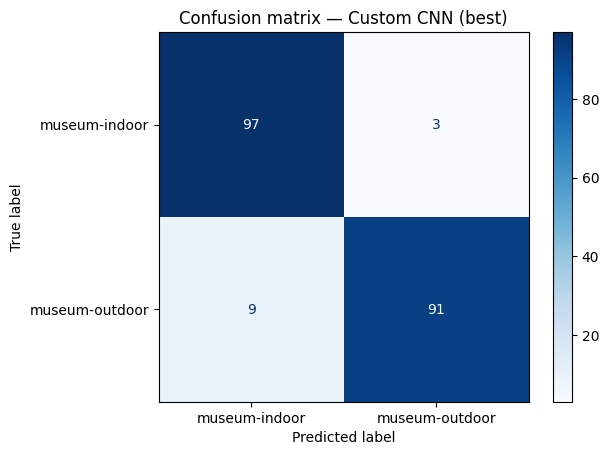


===== ResNet18 (backbone+head, 128px) =====
                precision    recall  f1-score   support

 museum-indoor     0.9703    0.9800    0.9751       100
museum-outdoor     0.9798    0.9700    0.9749       100

      accuracy                         0.9750       200
     macro avg     0.9750    0.9750    0.9750       200
  weighted avg     0.9750    0.9750    0.9750       200



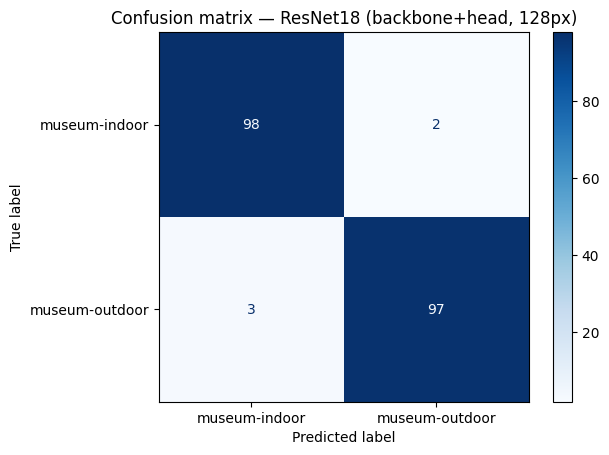

,accuracy,precision,recall,f1
model,,,,
Custom CNN (best),0.940,0.9416,0.940,0.9399
"ResNet18 (backbone+head, 128px)",0.975,0.9750,0.975,0.9750


In [21]:
summary = []
summary.append(evaluate_model(best_cnn, test_loader, "Custom CNN (best)"))
# ResNet evaluated on the SAME 128px test_loader as the custom CNN (controlled comparison).
summary.append(evaluate_model(resnet, test_loader, "ResNet18 (backbone+head, 128px)"))

cmp_df = pd.DataFrame(summary).set_index("model").round(4)
cmp_df


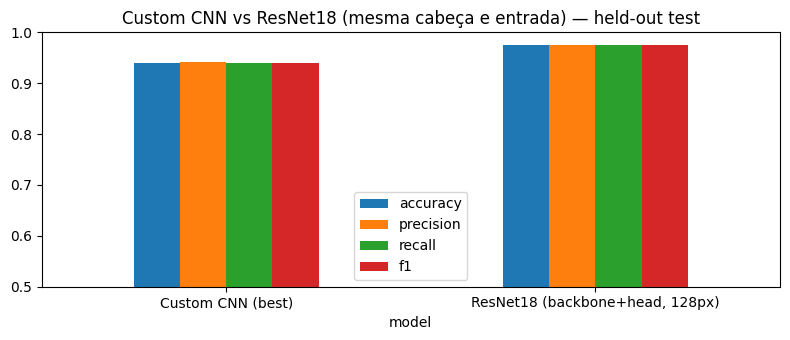

In [ ]:
cmp_df[["accuracy", "precision", "recall", "f1"]].plot.bar(figsize=(8, 3.5), rot=0,
                                                           ylim=(0.5, 1.0))
plt.title("Custom CNN vs ResNet18 (same head and input) — held-out test")
plt.tight_layout(); plt.show()


## VIII-b. Sensitivity check — ResNet18 at its native 224 resolution

Measures **how much** equalizing the input to 128px cost ResNet. Here only the **input
resolution** changes (224×224, ResNet's pretraining size); normalization is ImageNet in both
this check and the main comparison, and the model architecture is identical to Section VII.
Since the head starts with `AdaptiveAvgPool(4×4)`, the same model accepts 128 or 224 with no
layer changes.

Reading `ΔF1` (224 native − 128 controlled): **≈ 0** → the main comparison at 128 did **not**
penalize ResNet;


[resnet18_224_shared] resumed from checkpoint — epoch 3 (best val loss 0.0745)


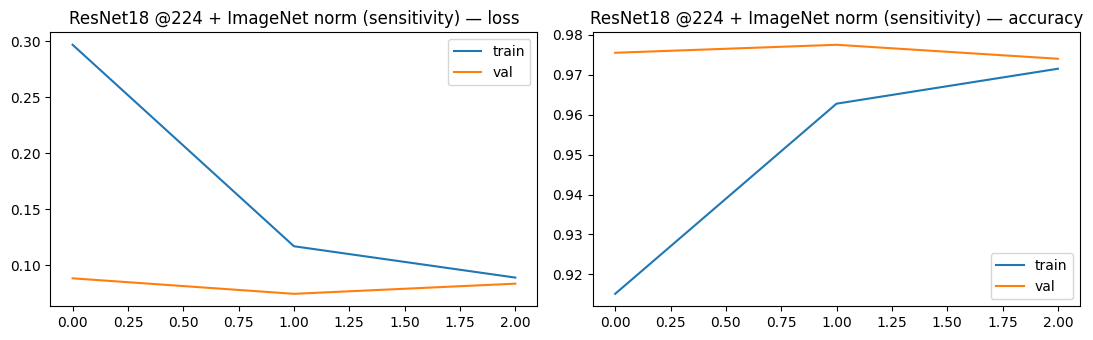


===== ResNet18 (backbone+head, 224px) =====
                precision    recall  f1-score   support

 museum-indoor     0.9703    0.9800    0.9751       100
museum-outdoor     0.9798    0.9700    0.9749       100

      accuracy                         0.9750       200
     macro avg     0.9750    0.9750    0.9750       200
  weighted avg     0.9750    0.9750    0.9750       200



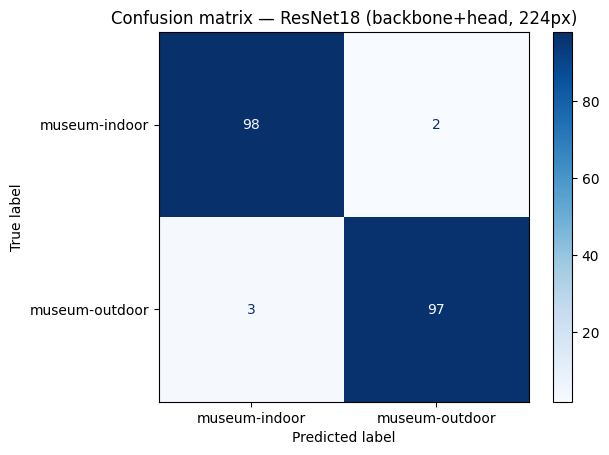

                                 accuracy  precision  recall      f1
model                                                               
Custom CNN (best)                   0.940     0.9416   0.940  0.9399
ResNet18 (backbone+head, 128px)     0.975     0.9750   0.975  0.9750
ResNet18 (backbone+head, 224px)     0.975     0.9750   0.975  0.9750

DeltaF1 (224 native - 128 controlled) = +0.0000
Delta ~0    -> the main 128px comparison did NOT penalize ResNet.
Delta large -> part of the gap came from input format, not the extractor.


In [24]:
RUN_SENSITIVITY = True   # set False to skip this check

if RUN_SENSITIVITY:
    IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    R = CFG["resnet_size"]   # 224

    # loaders in ResNet's NATIVE format (224 + ImageNet norm)
    rn_train_tf = transforms.Compose([
        transforms.RandomResizedCrop(R, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    rn_eval_tf = transforms.Compose([
        transforms.Resize((R, R)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    rn_train = Subset(datasets.ImageFolder(TRAIN_DIR, transform=rn_train_tf), train_idx)
    rn_val   = Subset(datasets.ImageFolder(TRAIN_DIR, transform=rn_eval_tf),  val_idx)
    rn_test  = datasets.ImageFolder(HELDOUT_DIR, transform=rn_eval_tf)
    kw = dict(num_workers=CFG["num_workers"], pin_memory=True)
    rn224_train_loader = DataLoader(rn_train, batch_size=32, shuffle=True,  **kw)
    rn224_val_loader   = DataLoader(rn_val,   batch_size=32, shuffle=False, **kw)
    rn224_test_loader  = DataLoader(rn_test,  batch_size=32, shuffle=False, **kw)

    # SAME model as Section VII -- only the INPUT changes
    resnet224 = build_resnet_classifier(FREEZE_BACKBONE)
    resnet224, hist_rn224 = fit(resnet224, rn224_train_loader, rn224_val_loader,
                                epochs=3, lr=1e-4, patience=2, tag="resnet18_224_shared")
    plot_history(hist_rn224, "ResNet18 @224 + ImageNet norm (sensitivity)")

    # evaluate on the 224 test set and append to the comparison table
    summary.append(evaluate_model(resnet224, rn224_test_loader,
                                  "ResNet18 (backbone+head, 224px)"))
    cmp_df = pd.DataFrame(summary).set_index("model").round(4)
    print(cmp_df)

    delta = (cmp_df.loc["ResNet18 (backbone+head, 224px)", "f1"]
             - cmp_df.loc["ResNet18 (backbone+head, 128px)", "f1"])
    print(f"\nDeltaF1 (224 native - 128 controlled) = {delta:+.4f}")
    print("Delta ~0    -> the main 128px comparison did NOT penalize ResNet.")
    print("Delta large -> part of the gap came from input format, not the extractor.")


## IX. Loading a saved model & running it on the test folder

Demonstrates the required "run a saved model on the test dataset" functionality.

In [ ]:
def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE)
    model = MuseumCNN(**ckpt["arch_kwargs"])
    model.load_state_dict(ckpt["state_dict"])
    return model.eval().to(DEVICE), ckpt

loaded_cnn, ckpt = load_model(MODEL_DIR / "museum_cnn_best.pt")
# sanity check: same metrics as before
_ = evaluate_model(loaded_cnn, test_loader, "Reloaded custom CNN", show_cm=False)


===== Reloaded custom CNN =====
                precision    recall  f1-score   support

 museum-indoor     0.9151    0.9700    0.9417       100
museum-outdoor     0.9681    0.9100    0.9381       100

      accuracy                         0.9400       200
     macro avg     0.9416    0.9400    0.9399       200
  weighted avg     0.9416    0.9400    0.9399       200



In [ ]:
# Batch inference over the unlabeled test/ folder -> predictions CSV
@torch.no_grad()
def predict_folder(model, folder: Path, out_csv="test_predictions.csv"):
    tf = transforms.Compose([transforms.Resize((S, S)), transforms.ToTensor(),
                             transforms.Normalize(NORM_MEAN, NORM_STD)])
    rows = []
    files = [p for p in sorted(folder.rglob("*"))
             if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}]
    for p in files:
        x = tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        prob = F.softmax(model(x), dim=1)[0].cpu().numpy()
        rows.append((p.name, CLASS_NAMES[prob.argmax()], *prob.round(4)))
    df = pd.DataFrame(rows, columns=["file", "prediction", *CLASS_NAMES])
    df.to_csv(out_csv, index=False)
    print(f"{len(df)} predictions saved -> {out_csv}")
    return df

if UNLABELED_DIR.exists():
    preds_df = predict_folder(loaded_cnn, UNLABELED_DIR)
    preds_df.head(10)

1 predictions saved -> test_predictions.csv


## X. Application mode — single image & live demo

Predict any individual image, showing the class and probabilities. The second cell uses
Colab's upload widget for **live inference during the demo**.

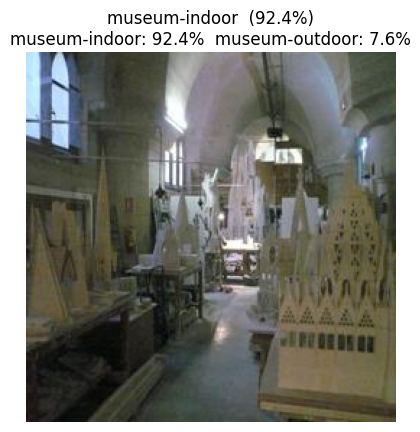

('museum-indoor', {'museum-indoor': 0.9240999817848206, 'museum-outdoor': 0.07590000331401825})


In [ ]:
@torch.no_grad()
def predict_image(model, img_path, show=True):
    img = Image.open(img_path).convert("RGB")
    tf = transforms.Compose([transforms.Resize((S, S)), transforms.ToTensor(),
                             transforms.Normalize(NORM_MEAN, NORM_STD)])
    prob = F.softmax(model(tf(img).unsqueeze(0).to(DEVICE)), dim=1)[0].cpu().numpy()
    pred = CLASS_NAMES[prob.argmax()]
    if show:
        plt.imshow(img); plt.axis("off")
        plt.title(f"{pred}  ({prob.max():.1%})\n" +
                  "  ".join(f"{c}: {p:.1%}" for c, p in zip(CLASS_NAMES, prob)))
        plt.show()
    return pred, dict(zip(CLASS_NAMES, prob.round(4).tolist()))

# Example: predict one image from the held-out set
example = test_ds.samples[2][0]
print(predict_image(loaded_cnn, example))

In [ ]:
# LIVE DEMO (Colab): upload any image and get prediction + probabilities
try:
    from google.colab import files
    uploaded = files.upload()
    for fname in uploaded:
        print(predict_image(loaded_cnn, fname))
except ImportError:
    print("Run this cell in Colab to upload an image live.")